# CNN Classifier — 4-Class Propeller Damage

Trains a small CNN to classify segments into: normal / 1-broken / 2-broken / 3-4-broken.

Run this notebook twice — once with `REPRESENTATION = 'mel'`, once with `'fft'` —
to compare which representation gives better classification accuracy.
Plots are saved to `plots/classifier_{representation}_*.png`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from pathlib import Path

REPRESENTATION = 'fft'   # 'mel' or 'fft'
NUM_CLASSES    = 4
BATCH_SIZE     = 64
EPOCHS         = 50
VAL_SPLIT      = 0.1
SEED           = 42

CLASS_NAMES = ['normal', '1_broken', '2_broken', '3_4_broken']

DATA_DIR  = Path('../processing') / REPRESENTATION
MODEL_DIR = Path('models')
PLOTS_DIR = Path('plots')
MODEL_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

## Load data

In [10]:
train = np.load(DATA_DIR / 'train.npz')
test  = np.load(DATA_DIR / 'test.npz')

X_train = train['X'][..., np.newaxis].astype(np.float32)  # (N, 32, 32, 1)
y_train = train['y_class'].astype(np.int32)

X_test  = test['X'][..., np.newaxis].astype(np.float32)
y_test  = test['y_class'].astype(np.int32)

print(f'Train: {X_train.shape}  class counts: {dict(zip(*np.unique(y_train, return_counts=True)))}') 
print(f'Test:  {X_test.shape}   class counts: {dict(zip(*np.unique(y_test,  return_counts=True)))}')

Train: (24801, 32, 32, 1)  class counts: {np.int32(0): np.int64(6773), np.int32(1): np.int64(6040), np.int32(2): np.int64(5898), np.int32(3): np.int64(6090)}
Test:  (6047, 32, 32, 1)   class counts: {np.int32(0): np.int64(1728), np.int32(1): np.int64(1410), np.int32(2): np.int64(1431), np.int32(3): np.int64(1478)}


## Build model

Three conv+pool stages keep parameter count low for quantisation to INT8.
Target: <50k parameters so the quantised model fits well within 1 MB flash.

In [11]:
def build_classifier(num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=(32, 32, 1))

    x = layers.Conv2D(8, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)           # (16, 16, 8)

    x = layers.Conv2D(16, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)           # (8, 8, 16)

    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)           # (4, 4, 32)

    x = layers.Flatten()(x)                # 512
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='classifier')
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

model = build_classifier()
model.summary()

Model: "classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,204 (153.14 KB)

 Trainable params: 39,092 (152.70 KB)

 Non-trainable params: 112 (448.00 B)

## Train

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ModelCheckpoint(
        MODEL_DIR / f'classifier_{REPRESENTATION}.keras',
        save_best_only=True, monitor='val_loss'
    ),
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8130 - loss: 0.4436 - val_accuracy: 0.9629 - val_loss: 0.0980
Epoch 2/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9133 - loss: 0.2185 - val_accuracy: 0.9855 - val_loss: 0.0480
Epoch 3/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9312 - loss: 0.1736 - val_accuracy: 0.9919 - val_loss: 0.0291
Epoch 4/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9412 - loss: 0.1444 - val_accuracy: 0.9927 - val_loss: 0.0250
Epoch 5/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9489 - loss: 0.1276 - val_accuracy: 0.9903 - val_loss: 0.0356
Epoch 6/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9529 - loss: 0.1119 - val_accuracy: 0.9923 - val_loss: 0.0271
Epoch 7/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9581 - loss: 0.1016 - val_accuracy: 0.9891 - val_loss: 0.0386
Epoch 8/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9601 - loss: 0.0928 - val_acc

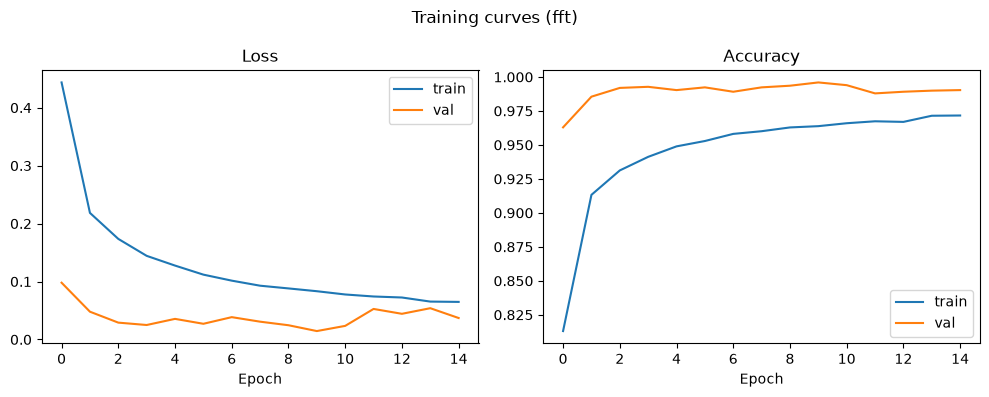

In [13]:
# Plot loss history
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

fig.suptitle(f'Training curves ({REPRESENTATION})')
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'classifier_{REPRESENTATION}_loss.png', dpi=100)
plt.show()

## Evaluate

In [14]:
# Check F1
y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)  # (N, 4)
y_pred = y_prob.argmax(axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f'Macro F1: {macro_f1:.4f}')

              precision    recall  f1-score   support

      normal       0.99      1.00      1.00      1728
    1_broken       0.99      0.96      0.98      1410
    2_broken       0.93      0.92      0.92      1431
  3_4_broken       0.93      0.96      0.94      1478

    accuracy                           0.96      6047
   macro avg       0.96      0.96      0.96      6047
weighted avg       0.96      0.96      0.96      6047

Macro F1: 0.9596


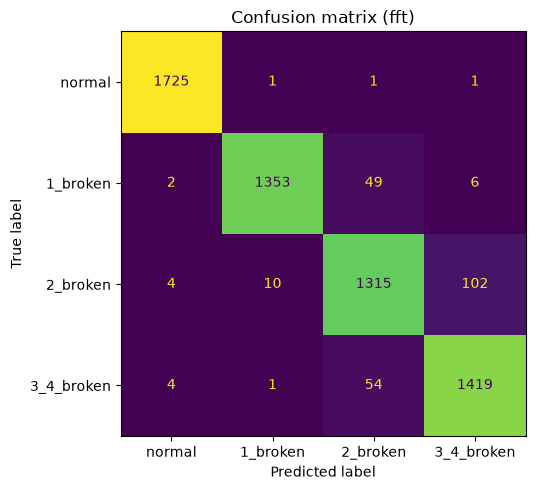

In [15]:
# Create full confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f'Confusion matrix ({REPRESENTATION})')
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'classifier_{REPRESENTATION}_confusion.png', dpi=100)
plt.show()

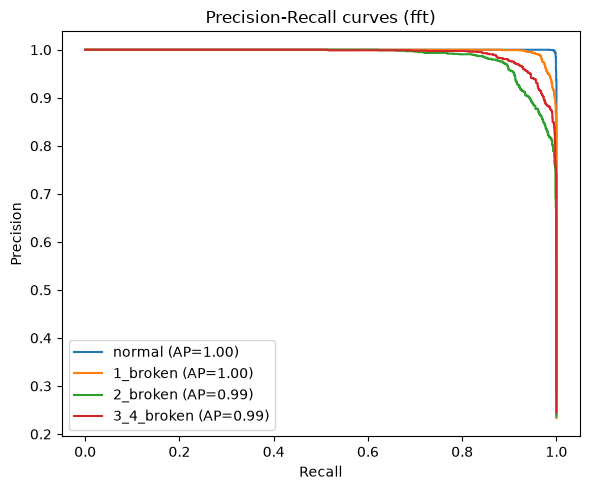

In [16]:
# Create precision-recall curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

y_test_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(6, 5))
for i, name in enumerate(CLASS_NAMES):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_prob[:, i])
    ax.plot(recall, precision, label=f'{name} (AP={ap:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall curves ({REPRESENTATION})')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig(PLOTS_DIR / f'classifier_{REPRESENTATION}_pr_curve.png', dpi=100)
plt.show()